Nome: Vinícius Barbosa Bassete 

RA: 248135 

Curso: Mestrado em Física Aplicada 

# DEMO de Contador de moedas 
### O código apresentado realizará a contagem do valor monetário total de moedas contidas em uma imagem, para isso, utiliza operações de threshold, closing, opening, labeling e por fim, uma breve análise do tamanho das regiões segmentadas. O código foi baseado no exemplo dado no enunciado do exercício e com as referências das funções aprensentadas na documentação do skimage (https://scikit-image.org/docs/0.25.x/api/skimage.morphology.html)

### Todos os parâmetros e valores de threshold (exceto quando utilizado Otsu) foram escolhidos manualmente buscando o melhor resultado. 



In [ ]:
# ----------------------------------- BIBLIOTECAS UTILIZADAS ----------------------------------------
import numpy as np
from PIL import Image
from skimage.filters import threshold_otsu
from skimage.morphology import binary_closing, binary_opening, label, disk   # por ter mais familiariedade, utilizei as funções morfológicas do skimage.
from matplotlib import pyplot as plt
# ---------------------------------------------------------------------------------------------------

c:\Users\vbass\AppData\Local\Programs\Python\Python312\Lib\site-packages\skimage\filters\thresholding.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  from scipy import ndimage as ndi


In [ ]:

def conta_troco(IMG, DISK_R = 8, PLOT=True): # a função printa a soma dos valores das moedas.
    img = Image.open(IMG) #carrega a imagem contendo as moedas
    img_gray = np.asarray(img.convert('L')).copy() # converte a imagem para tons de cinza
    threshold = threshold_otsu(img_gray) # utiliza o método de ajuste de threshold de otsu, assim, consigo threshold específico para cada imagem
    print('Threshold Otsu: ', threshold) # mostro o threshold ajustado
    bool_array = (img_gray <= threshold) # crio um array booleano filtrando os valores de pixel menores do que o threshold
    mask = np.where(bool_array,1,0) #crio a máscara na condição de que os valores 1 correspondem a uma moeda


    mask_closing = binary_closing(mask, disk(DISK_R)) # operação de closing para fechar as imperfeições do threshold dentro das moedas

    mask_opening = binary_opening(mask_closing, disk(DISK_R*3)) # operação de opening para consertar as bordas das moedas e garantir que elas não se grudem após o closing

    mask_labeling = label(mask_opening,background=0) # operação de labeling, que atribui um número para cada 'cluster' de 1's na imagem

    pixel_counts = []
    max_label_idx = mask_labeling.max() # pega o número total de clusters na imagem através dos labels
    valor_total = 0
    for i in range(1,max_label_idx+1): 
        soma_pixels = np.sum(mask_labeling==i) # soma o número de pixels em cada cluster através da label
        if soma_pixels <= 3800: # a moeda de 10 eh menor (threshold ajustado na mão)
            valor_total += 10 
            pixel_counts.append([soma_pixels,10])
        elif soma_pixels < 5000: # a moeda de 5 é média (threshold ajustado na mão)
            valor_total += 5 
            pixel_counts.append([soma_pixels,5])
        else:  # a moeda de 25 é a maior (threshold ajustado na mão)
            valor_total += 25 
            pixel_counts.append([soma_pixels,25])

        
    print(f'Contei {valor_total} centavos') #mostra o total de centavos na imagem

    if PLOT:   # se quiser, mostra as imagens passo a passo.
        plt.subplot(3,2,1)
        plt.imshow(img,cmap='gray')
        plt.axis('off')
        plt.subplot(3,2,2)
        plt.imshow(img_gray,cmap='gray')
        plt.axis('off')
        plt.subplot(3,2,3)
        plt.imshow(mask_closing,cmap='gray')
        plt.axis('off')
        plt.subplot(3,2,4)
        plt.imshow(mask_opening,cmap='gray')
        plt.axis('off') 
        plt.subplot(3,2,5)
        plt.imshow(mask_labeling,cmap='gray')
        plt.axis('off')
        plt.show()


Threshold Otsu:  105
Contei 75 centavos


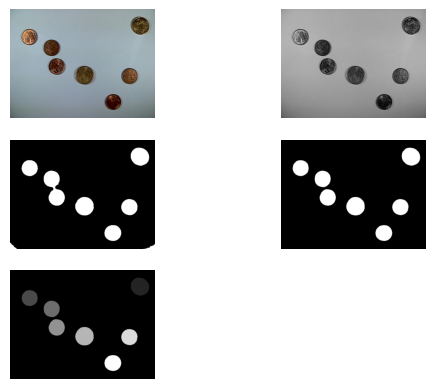

--------------------------------------------------------------------------------
Threshold Otsu:  92
Contei 80 centavos


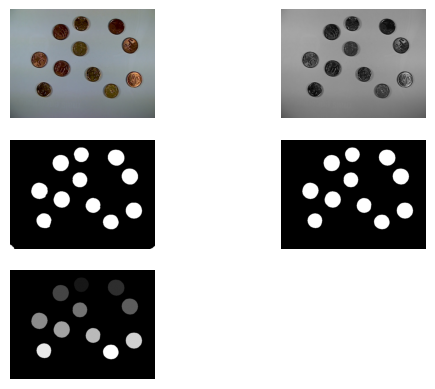

--------------------------------------------------------------------------------
Threshold Otsu:  94
Contei 95 centavos


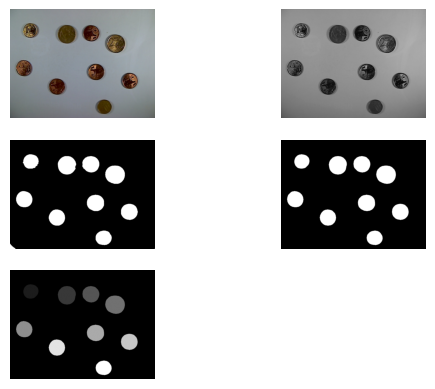

--------------------------------------------------------------------------------


In [ ]:
for IMG in ['75.jpg','80.jpg', '95.jpg']: # itera nas imagens disponíveis
    conta_troco(IMG) # roda a funcao
    print('-'*80) 